# Notebook 1: Energy Attribution to Callgraph Functions

This notebook demonstrates our method for attributing GPU energy consumption to individual
functions in the MPI call graph. For each benchmark discovered under `app-traces/`, we:

1. Exclusively attribute per-device energy samples to the deepest active call at each time point
2. Visualize the call-tree structure as a **flame chart** with power overlay
3. Show a **per-rank energy heatmap** highlighting load imbalance across MPI ranks
4. Compare **library energy breakdown** across all available benchmarks


In [33]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.collections import PatchCollection
from pathlib import Path
from scipy.stats import gaussian_kde

from ampere import Ensemble, MetricConfig, MetricType, connect, set_backend, DataFrame

set_backend('pandas')
connect(server="localhost", port=5555)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})
BG = '#fafafa'

ENERGY_DEVICES = [f"A2rocm_smi:::energy_count:device={d}" for d in [0, 2, 4, 6]]

# Library classification colors
PALETTE = {
    'rocBLAS':     '#2d6a4f',
    'rocSOLVER':   '#e07a3a',
    'HIP Runtime': '#9b5de5',
    'HPL':         '#4cc9f0',
    'MPI':         '#adb5bd',
    'Other':       '#6c757d',
}
LIB_ORDER = ['rocBLAS', 'rocSOLVER', 'HIP Runtime', 'HPL', 'MPI', 'Other']


Pandas backend active — skipping Arkouda connection.


## 1. Data Discovery

Scan `app-traces/` and find every benchmark with CSV data. New benchmarks placed here will be picked up automatically.

In [34]:
APP_TRACES_ROOT = Path("./app-traces")

def discover_benchmarks(root: Path) -> dict:
    """Return {benchmark_name: Path(trial_dir)} for every trial with CSV data."""
    found = {}
    for bench in sorted(root.iterdir()):
        if not bench.is_dir():
            continue
        for trial in sorted(bench.iterdir()):
            if not trial.is_dir():
                continue
            csvs = (list(trial.glob("MPI Rank*_Master_thread_callgraph.csv")) +
                    list(trial.glob("MPI Rank*_callgraph.csv")))
            if csvs:
                found[bench.name] = trial
                break
        else:
            print(f"  [no data yet] {bench.name}")
    print(f"\nDiscovered {len(found)} benchmark(s): {list(found.keys())}")
    return found

BENCHMARKS = discover_benchmarks(APP_TRACES_ROOT)


  [no data yet] HPG-MxP-Full
  [no data yet] LSMS
  [no data yet] QMCPACK

Discovered 2 benchmark(s): ['HPL', 'HPL-MxP']


## 2. Helper Functions

In [35]:
def classify(name: str) -> str:
    n = name.lower().split('(')[0].strip()
    if n.startswith('mpi_'):         return 'MPI'
    if n.startswith('rocsolver'):    return 'rocSOLVER'
    if n.startswith('rocblas'):      return 'rocBLAS'
    if n.startswith('hip') or 'devicemalloc' in n or 'hostmalloc' in n:
        return 'HIP Runtime'
    if n.startswith('hpl_') or n.startswith('hplmxp') or n == 'main':
        return 'HPL'
    return 'Other'

def short_name(name: str) -> str:
    p = name.find('(')
    base = name[:p] if p != -1 else name
    a = base.find('<')
    return (base[:a] if a != -1 else base).strip()

def make_node_ranks(trial_path: Path) -> dict | None:
    """Infer node_ranks dict from CSV filenames in trial_path."""
    ranks = set()
    for f in trial_path.iterdir():
        if not f.is_file(): continue
        m = re.match(r"(MPI Rank \d+)_", f.name)
        if m: ranks.add(m.group(1))
    if ranks:
        return {"Node0": sorted(ranks, key=lambda s: int(s.split()[-1]))}
    if any(f.name.startswith("Process_") for f in trial_path.iterdir() if f.is_file()):
        return {"Node0": ["Process"]}
    return None

def mpi_topology_resolver(metric_name, ranks):
    mapping = {'device=4': ('MPI Rank 0', 'MPI Rank 1'),
               'device=2': ('MPI Rank 2', 'MPI Rank 3'),
               'device=6': ('MPI Rank 4', 'MPI Rank 5'),
               'device=0': ('MPI Rank 6', 'MPI Rank 7')}
    for key, targets in mapping.items():
        if key in metric_name:
            return [r for r in ranks if r.name in targets]
    return ranks

def compute_combined_power(metrics_path: Path):
    """Differentiate energy counters to get combined instantaneous power."""
    dm = pd.read_csv(metrics_path)
    power_series = []
    for dev in [0, 2, 4, 6]:
        sub = dm[dm['Metric Name'] == f'A2rocm_smi:::energy_count:device={dev}'].sort_values('Time')
        if len(sub) < 2: continue
        t  = sub['Time'].values
        e  = sub['Value'].values * 1e-6   # µJ → J
        dt = np.diff(t)
        de = np.diff(e)
        p  = np.where((dt > 0) & (de >= 0), de / dt, 0.0)
        power_series.append((t[1:], p))
    if not power_series:
        return None, None
    min_len = min(len(pt) for pt, _ in power_series)
    t_ref   = power_series[0][0][:min_len]
    total_p = sum(np.interp(t_ref, pt, pv) for pt, pv in power_series)
    return t_ref, total_p


## Figure 1: Energy Flame Chart

Call-tree timeline for the first available benchmark (rank 0).  
Bar color = library family; bars at each depth row represent individual function calls.  
The power trace above shows the raw GPU power consumption over the same time window.

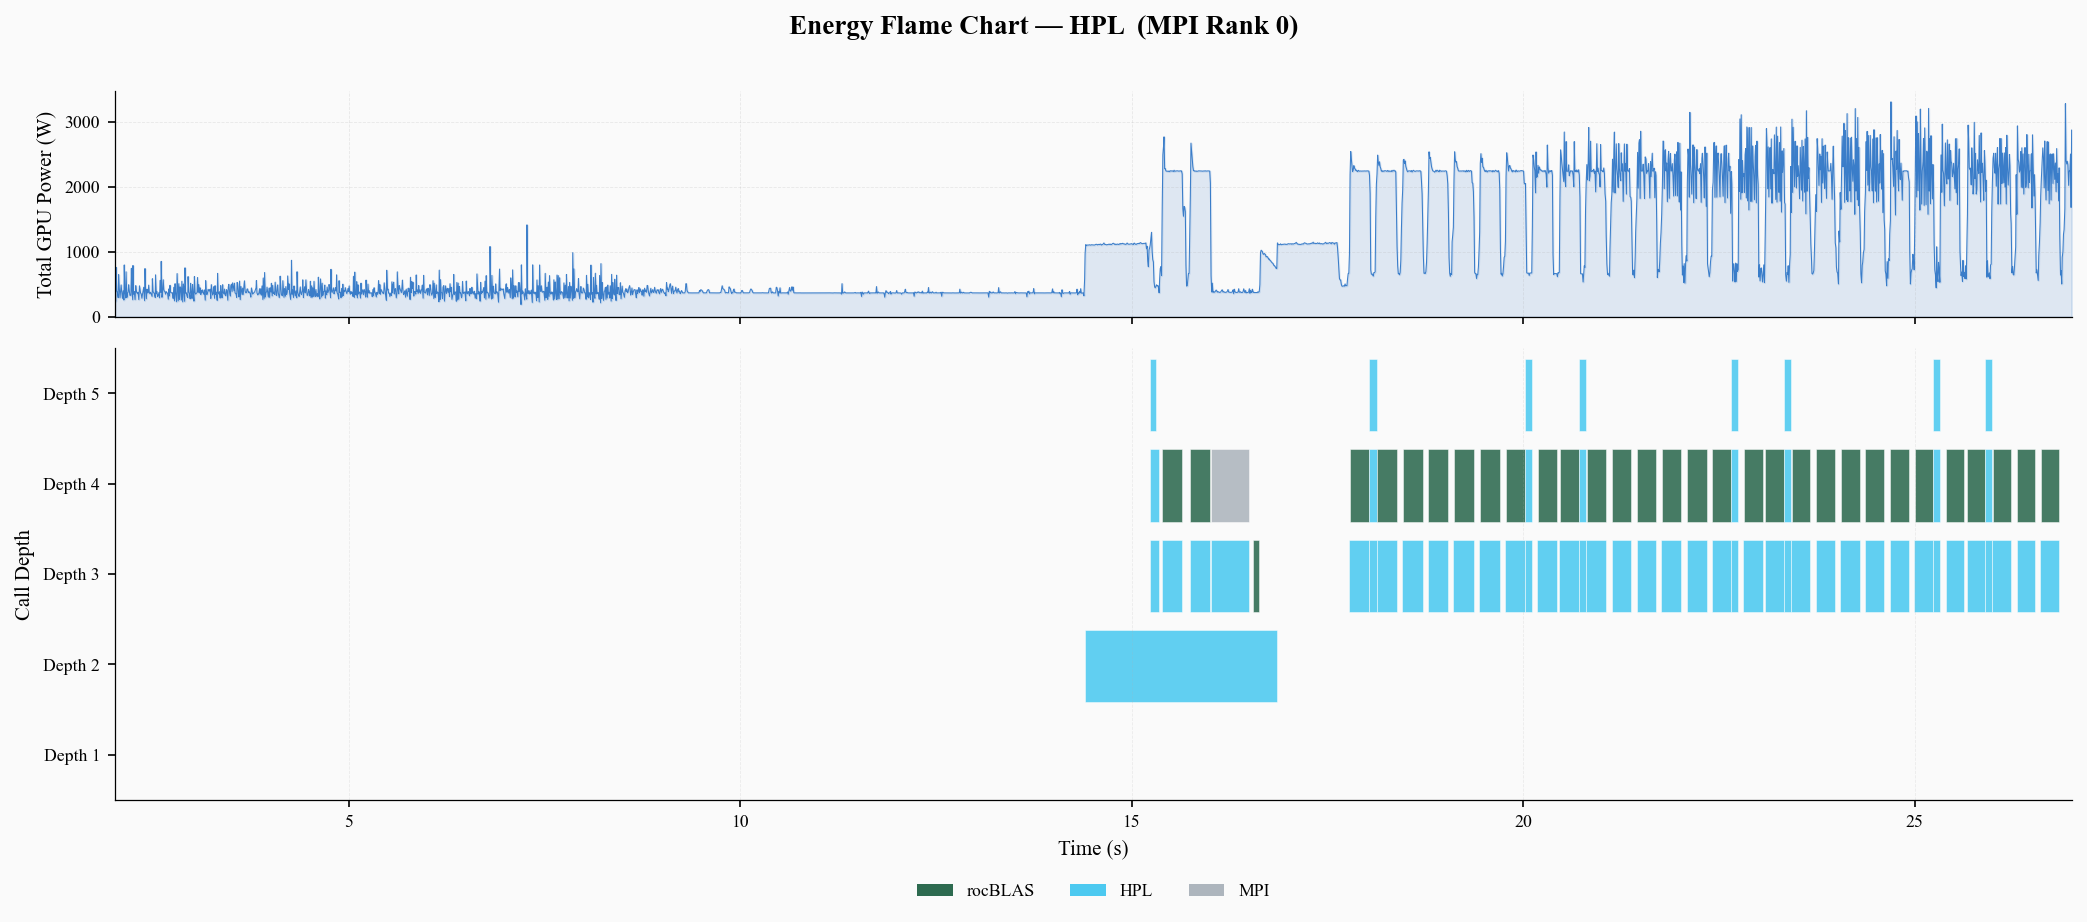

  Plotted 88 call bars across depths 1–5


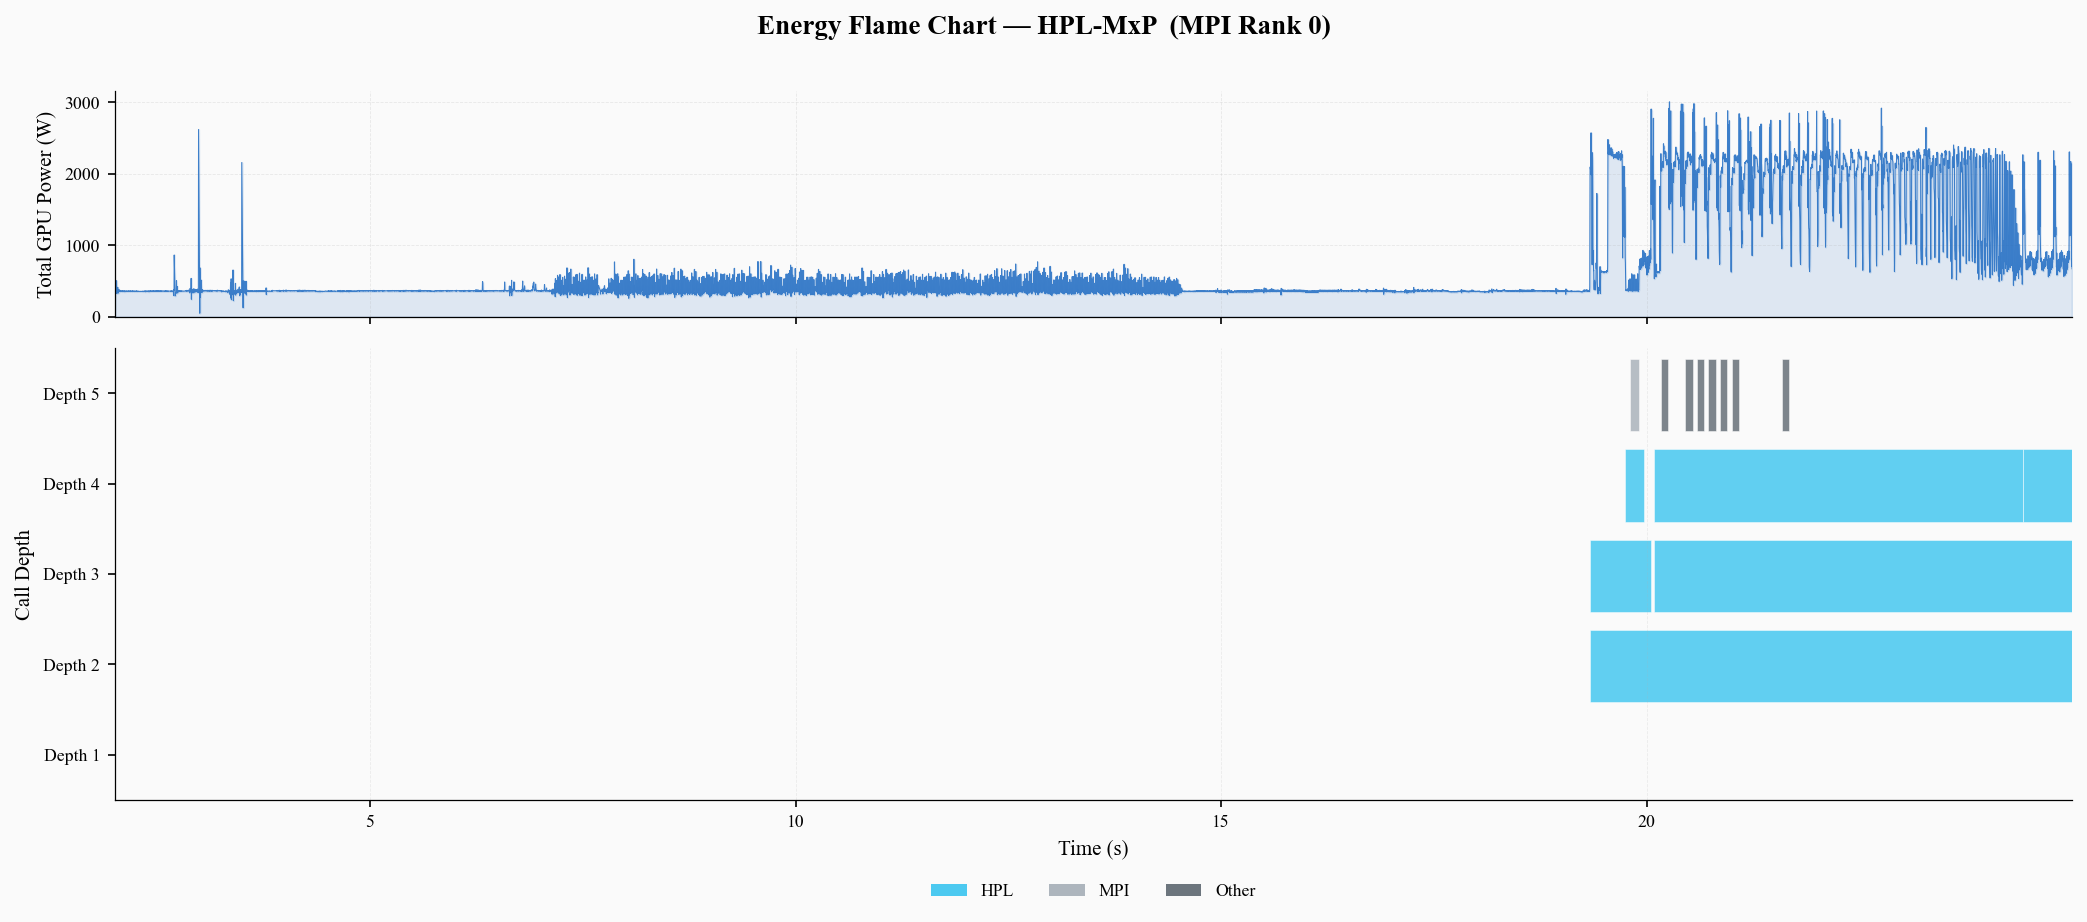

  Plotted 14 call bars across depths 1–5


In [36]:
configs = {
    re.compile(r".*energy_count.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def draw_flame_chart(bench_name: str, trial_path: Path,
                     rank_id: int = 0,
                     max_depth: int = 5,
                     min_dur_s: float = 0.08,
                     t_window: tuple | None = None,
                     save_prefix: str = "fig1"):
    cg_path = trial_path / f"MPI Rank {rank_id}_Master_thread_callgraph.csv"
    m_path  = trial_path / f"MPI Rank {rank_id}_metrics.csv"
    if not cg_path.exists() or not m_path.exists():
        print(f"  [skip] no files for rank {rank_id}")
        return

    # --- Load callgraph ---
    df = pd.read_csv(cg_path, usecols=['Depth', 'Name', 'Start Time', 'End Time'])
    df['Duration'] = df['End Time'] - df['Start Time']
    df = df[(df['Depth'] <= max_depth) & (df['Duration'] >= min_dur_s)].copy()
    df['Library'] = df['Name'].apply(classify)

    # Time window: skip first 2 s (MPI init), show up to 25 s of compute
    trace_start = df['Start Time'].min()
    trace_end   = df['End Time'].max()
    if t_window is None:
        t0 = trace_start + 2.0
        t1 = min(trace_end, t0 + 25.0)
        t_window = (t0, t1)
    df = df[(df['Start Time'] >= t_window[0]) & (df['End Time'] <= t_window[1])].copy()

    # --- Power trace ---
    power_t, power_v = compute_combined_power(m_path)
    if power_t is not None:
        mask    = (power_t >= t_window[0]) & (power_t <= t_window[1])
        power_t = power_t[mask]
        power_v = power_v[mask]

    # --- Plot ---
    fig, (ax_p, ax_f) = plt.subplots(2, 1, figsize=(14, 6), facecolor=BG,
                                      gridspec_kw={'height_ratios': [1, 2]},
                                      sharex=True)
    ax_p.set_facecolor(BG)
    ax_f.set_facecolor(BG)

    # Power panel
    if power_t is not None and len(power_t) > 0:
        ax_p.plot(power_t, power_v, lw=0.5, color='#1565C0', alpha=0.8)
        ax_p.fill_between(power_t, power_v, alpha=0.12, color='#1565C0')
        ax_p.set_ylabel('Total GPU Power (W)')
        ax_p.set_ylim(0)
        ax_p.grid(alpha=0.25, linestyle='--')

    # Flame chart: rectangles per call
    present_libs = []
    for _, row in df.iterrows():
        lib   = row['Library']
        color = PALETTE.get(lib, '#6c757d')
        rect  = mpatches.FancyBboxPatch(
            (row['Start Time'], row['Depth'] - 0.42),
            row['Duration'], 0.80,
            boxstyle="square,pad=0",
            facecolor=color, edgecolor='white', linewidth=0.25, alpha=0.88
        )
        ax_f.add_patch(rect)
        if lib not in present_libs:
            present_libs.append(lib)

    ax_f.set_xlim(*t_window)
    ax_f.set_ylim(0.5, max_depth + 0.5)
    ax_f.set_yticks(range(1, max_depth + 1))
    ax_f.set_yticklabels([f'Depth {d}' for d in range(1, max_depth + 1)])
    ax_f.set_xlabel('Time (s)')
    ax_f.set_ylabel('Call Depth')
    ax_f.grid(axis='x', alpha=0.2, linestyle='--')

    # Legend
    handles = [mpatches.Patch(facecolor=PALETTE[lib], label=lib)
               for lib in LIB_ORDER if lib in present_libs]
    ax_f.legend(handles=handles, frameon=False, ncol=len(handles),
                loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=8.5)

    fig.suptitle(f'Energy Flame Chart — {bench_name}  (MPI Rank {rank_id})',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.savefig(f'{save_prefix}_{bench_name}_flame.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()
    print(f"  Plotted {len(df):,} call bars across depths 1–{max_depth}")

for bench_name, trial_path in BENCHMARKS.items():
    draw_flame_chart(bench_name, trial_path)


## Figure 2: Exclusive Energy Heatmap

Rows = functions (sorted by total energy), columns = MPI ranks. Cell value = total exclusive energy (J) attributed to that function on that rank. Background color encodes magnitude — load imbalance shows up as hot/cold columns.

Loading Runs: 100%|██████████| 1/1 [00:11<00:00, 11.43s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.14s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.35s/it]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


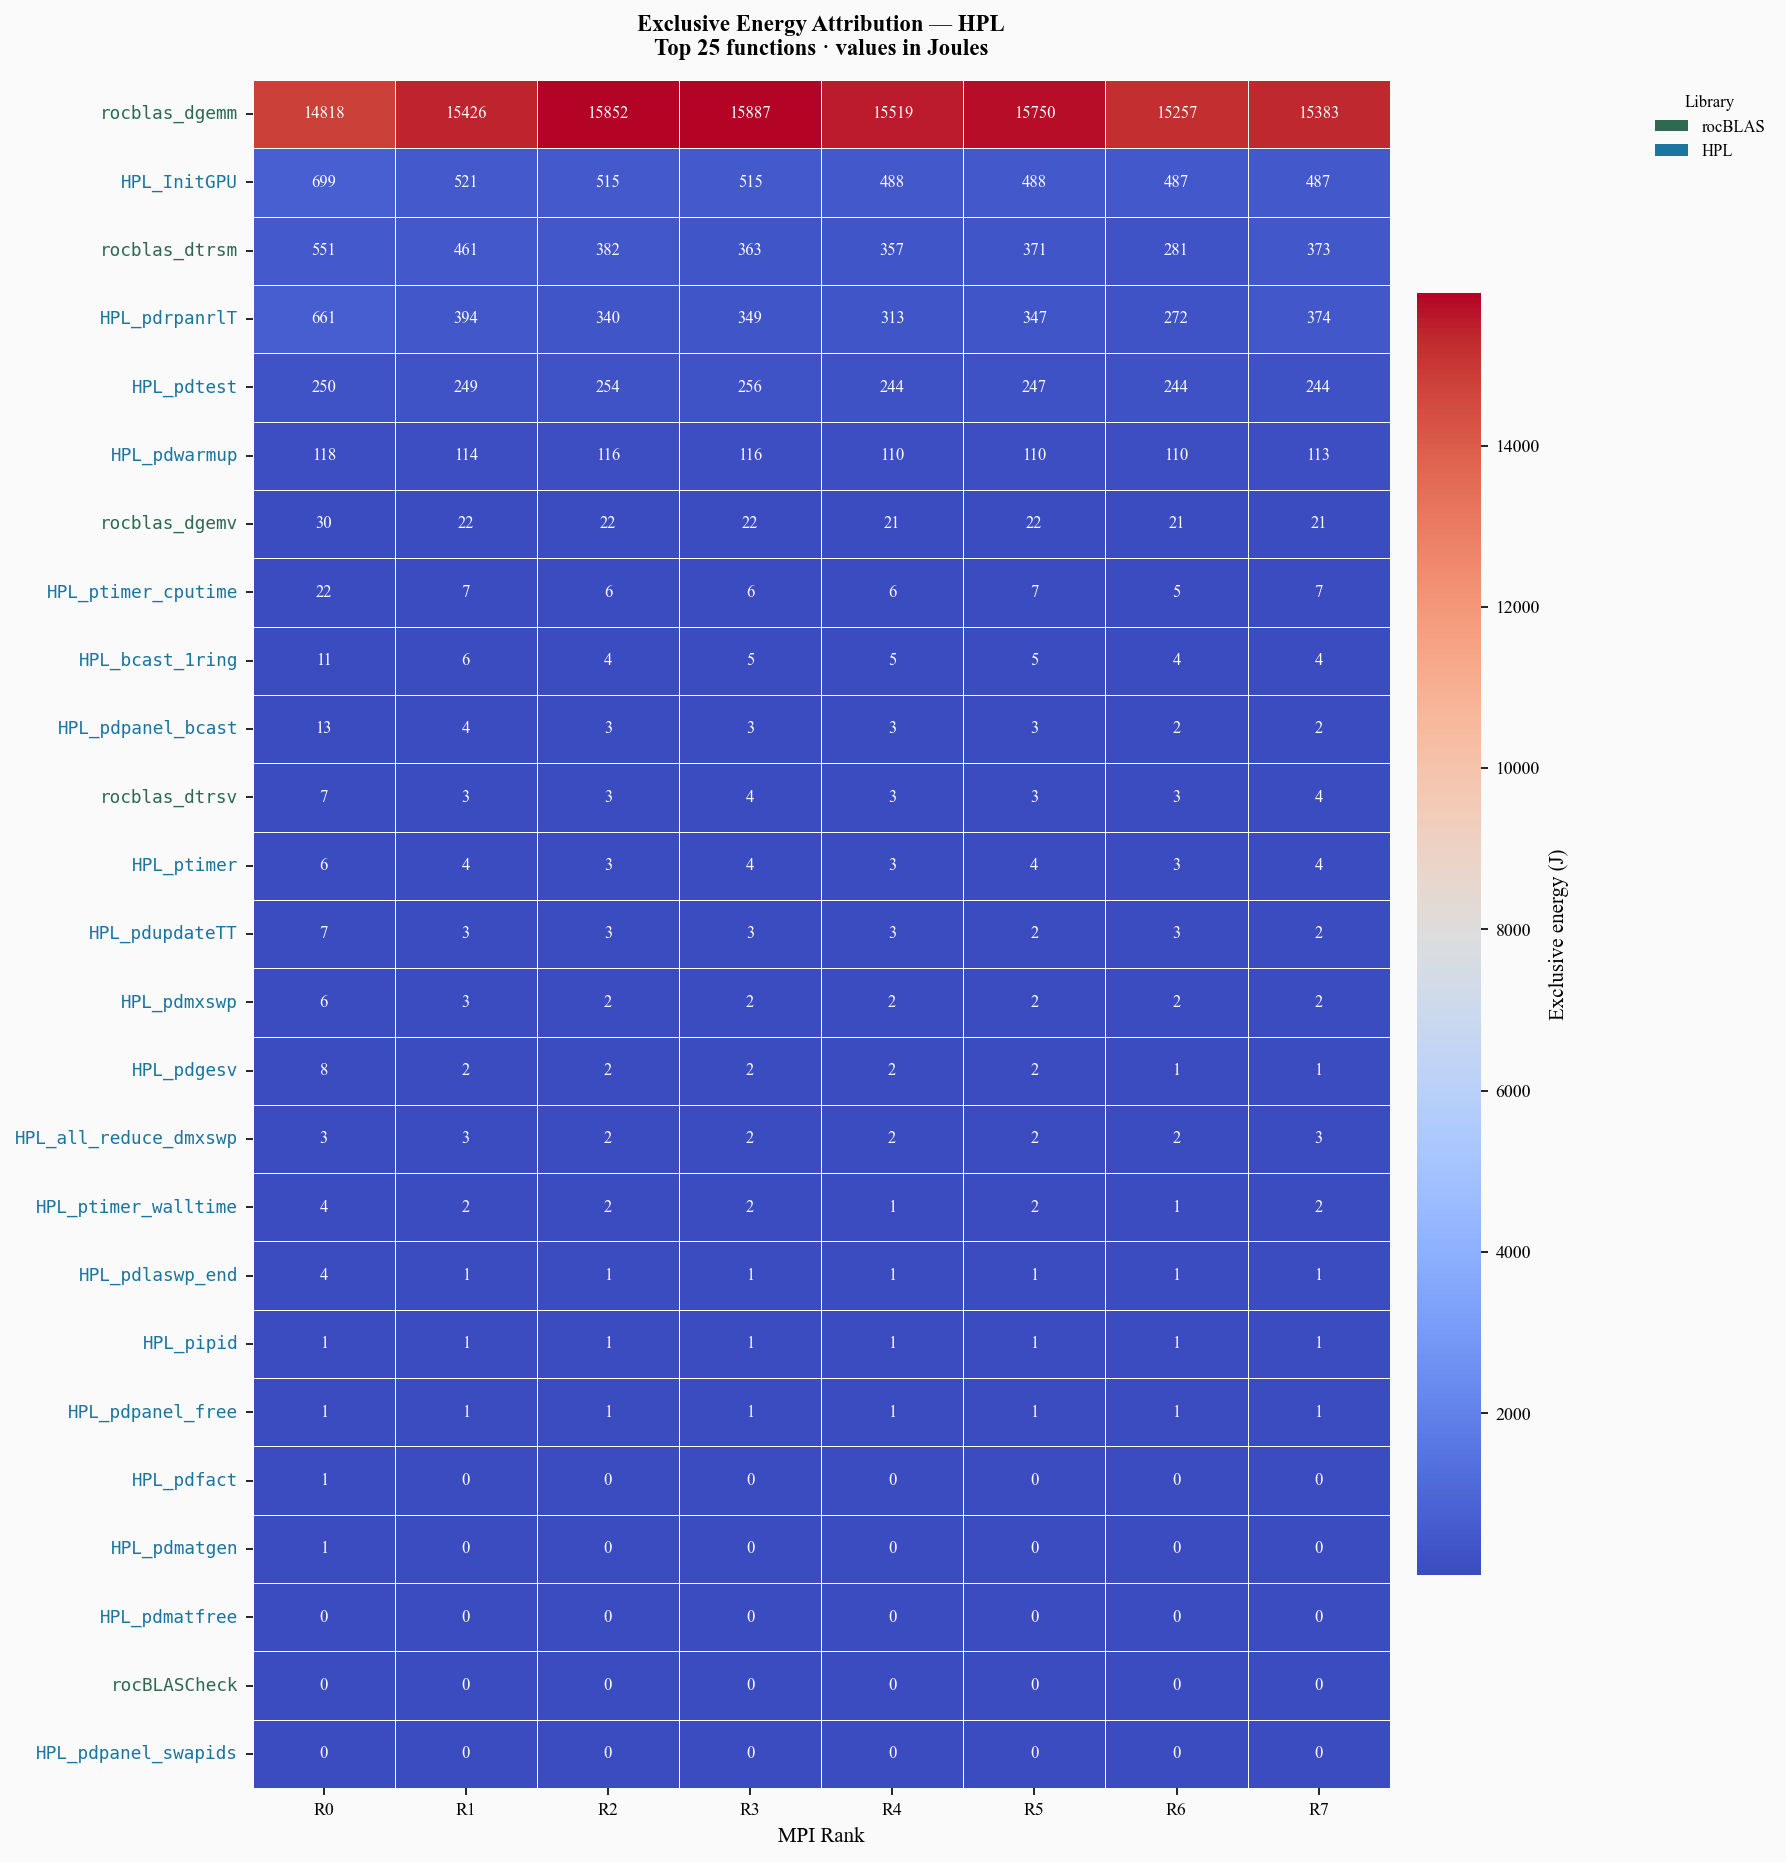

Loading Runs: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 13.73it/s]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 15.29it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 15.04it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 16.99it/s]


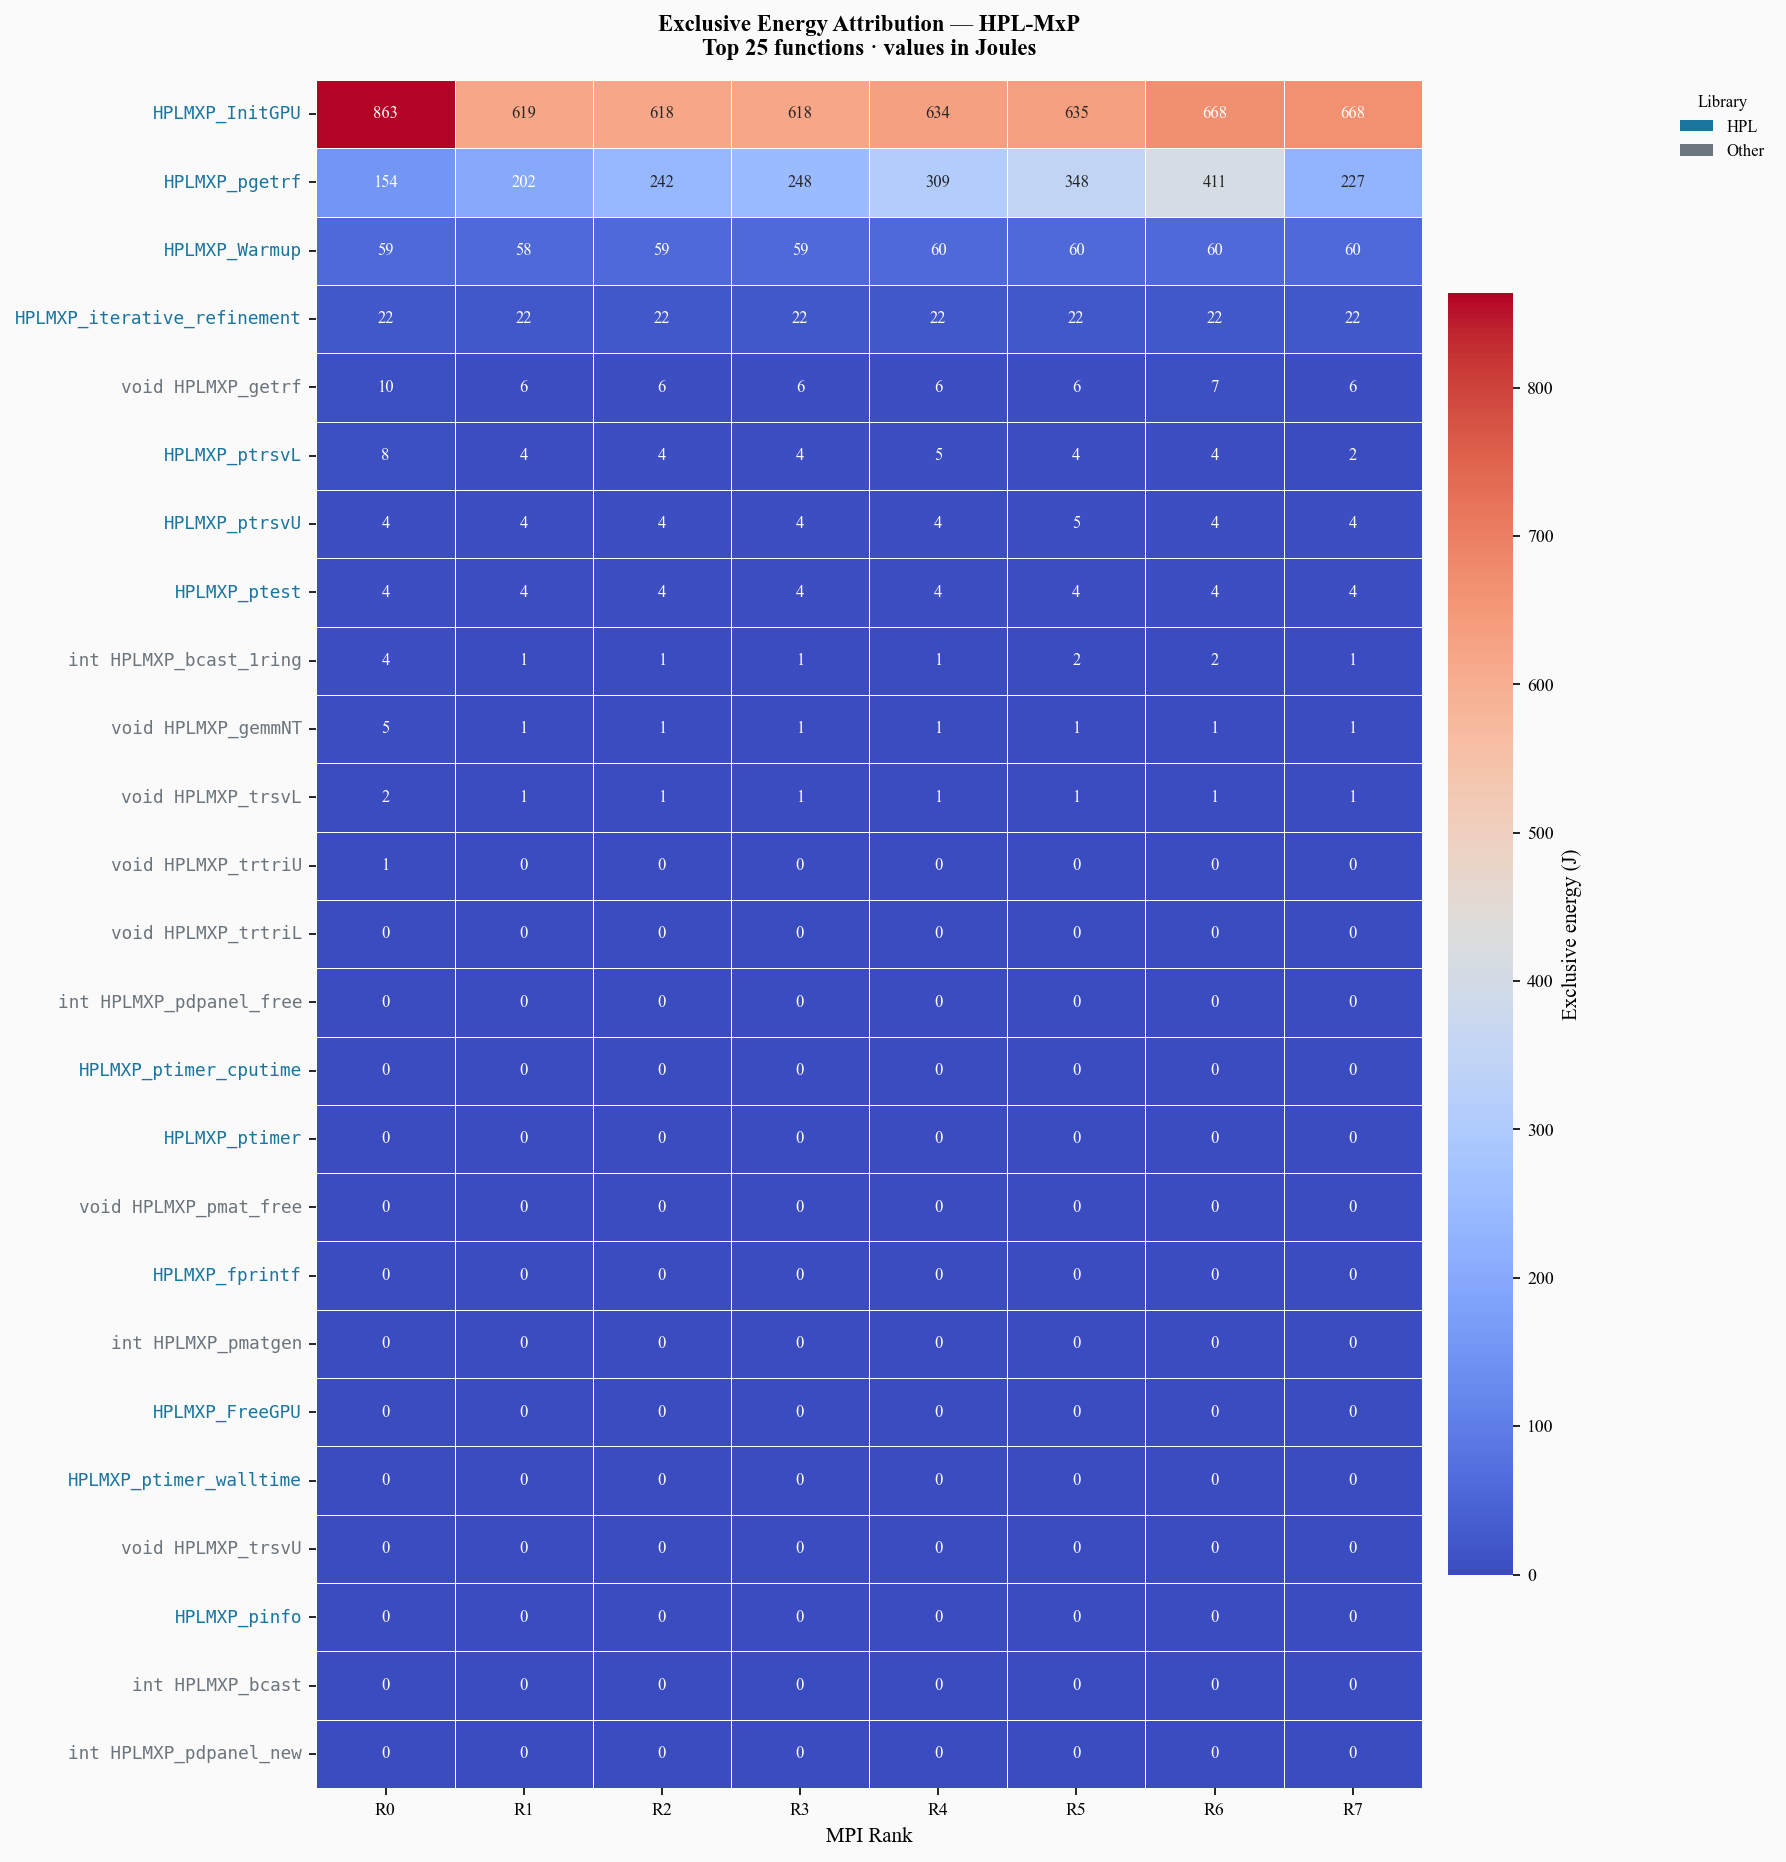

In [37]:
import seaborn as sns

def per_rank_energy_heatmap(bench_name: str, trial_path: Path,
                              top_n: int = 25, save_prefix: str = "fig2"):
    node_ranks = make_node_ranks(trial_path)
    if not node_ranks:
        print(f"  [skip] {bench_name}: no rank info"); return

    ens = Ensemble.from_trace_paths([str(trial_path)], node_ranks, configs)
    rank_dfs = []
    for metric in ENERGY_DEVICES:
        try:
            df = ens.attribute(metric, topology_resolver=mpi_topology_resolver,
                               strategy='exclusive').to_pandas()
            if len(df) > 0:
                rank_dfs.append(df)
        except Exception:
            pass
    if not rank_dfs:
        print(f"  [skip] {bench_name}: no attribution data"); return

    attr = pd.concat(rank_dfs, ignore_index=True)
    attr['ShortName'] = attr['Name'].apply(short_name)
    attr['Library']   = attr['Name'].apply(classify)
    attr = attr[attr['Library'] != 'MPI'].copy()

    pivot = (attr.groupby(['ShortName', 'Rank'])['Value'].sum()
               .unstack(fill_value=0.0))
    rank_cols = sorted(pivot.columns,
                       key=lambda s: int(re.search(r'\d+', s).group()))
    pivot = pivot[rank_cols].rename(
        columns={c: c.replace('MPI Rank ', 'R') for c in rank_cols})

    top_funcs = pivot.sum(axis=1).sort_values(ascending=False).head(top_n).index
    heat = pivot.loc[top_funcs]

    func_libs = attr.groupby('ShortName')['Library'].first().to_dict()
    LIB_HEX = {'rocBLAS': '#2d6a4f', 'rocSOLVER': '#e07a3a',
               'HIP Runtime': '#9b5de5', 'HPL': '#1a759f', 'Other': '#6c757d'}

    fig_h = max(6, len(top_funcs) * 0.42 + 2)
    fig_w = max(8, heat.shape[1] * 1.0 + 4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor=BG)
    ax.set_facecolor(BG)

    sns.heatmap(
        heat,
        annot=True,
        fmt='.0f',
        # cmap='YlOrRd',
        cmap='coolwarm',
        linewidths=0.4,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Exclusive energy (J)', 'shrink': 0.75, 'pad': 0.02},
        annot_kws={'size': 8},
    )

    # Color row (function) tick labels by library
    for tick_label in ax.get_yticklabels():
        fn  = tick_label.get_text()
        lib = func_libs.get(fn, 'Other')
        tick_label.set_color(LIB_HEX.get(lib, '#6c757d'))
        tick_label.set_fontsize(8.5)
        tick_label.set_fontfamily('monospace')

    ax.set_xlabel('MPI Rank', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8.5, rotation=0)
    ax.tick_params(axis='y', labelsize=8.5, rotation=0)
    ax.set_title(
        f'Exclusive Energy Attribution — {bench_name}\n'
        f'Top {len(top_funcs)} functions · values in Joules',
        fontweight='bold', pad=12)

    # Library color legend to the right of the colorbar
    lib_handles = [mpatches.Patch(facecolor=LIB_HEX[lib], label=lib)
                   for lib in LIB_HEX
                   if lib in {func_libs.get(fn, 'Other') for fn in top_funcs}]
    ax.legend(handles=lib_handles, frameon=False, fontsize=8,
              bbox_to_anchor=(1.22, 1), loc='upper left', title='Library',
              title_fontsize=8)

    fig.tight_layout()
    fig.savefig(f'{save_prefix}_{bench_name}_heatmap.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

for bench_name, trial_path in BENCHMARKS.items():
    per_rank_energy_heatmap(bench_name, trial_path)


## Figures 3 & 4: Exclusive and Inclusive Energy Flamegraphs

Both flamegraphs are time-ordered: X axis = real time, Y axis = call depth, each bar = one function call.  
**Exclusive** (Fig 3): bar color encodes only the energy this function consumed itself (child calls subtracted). Hot bars are the literal source of power draw.  
**Inclusive** (Fig 4): bar color encodes total energy flowing *through* the call (including all descendants). Shows which high-level routines own the most energy.

Building flame data for HPL …
  134 bars  ·  inclusive energy ≈ 18400 J


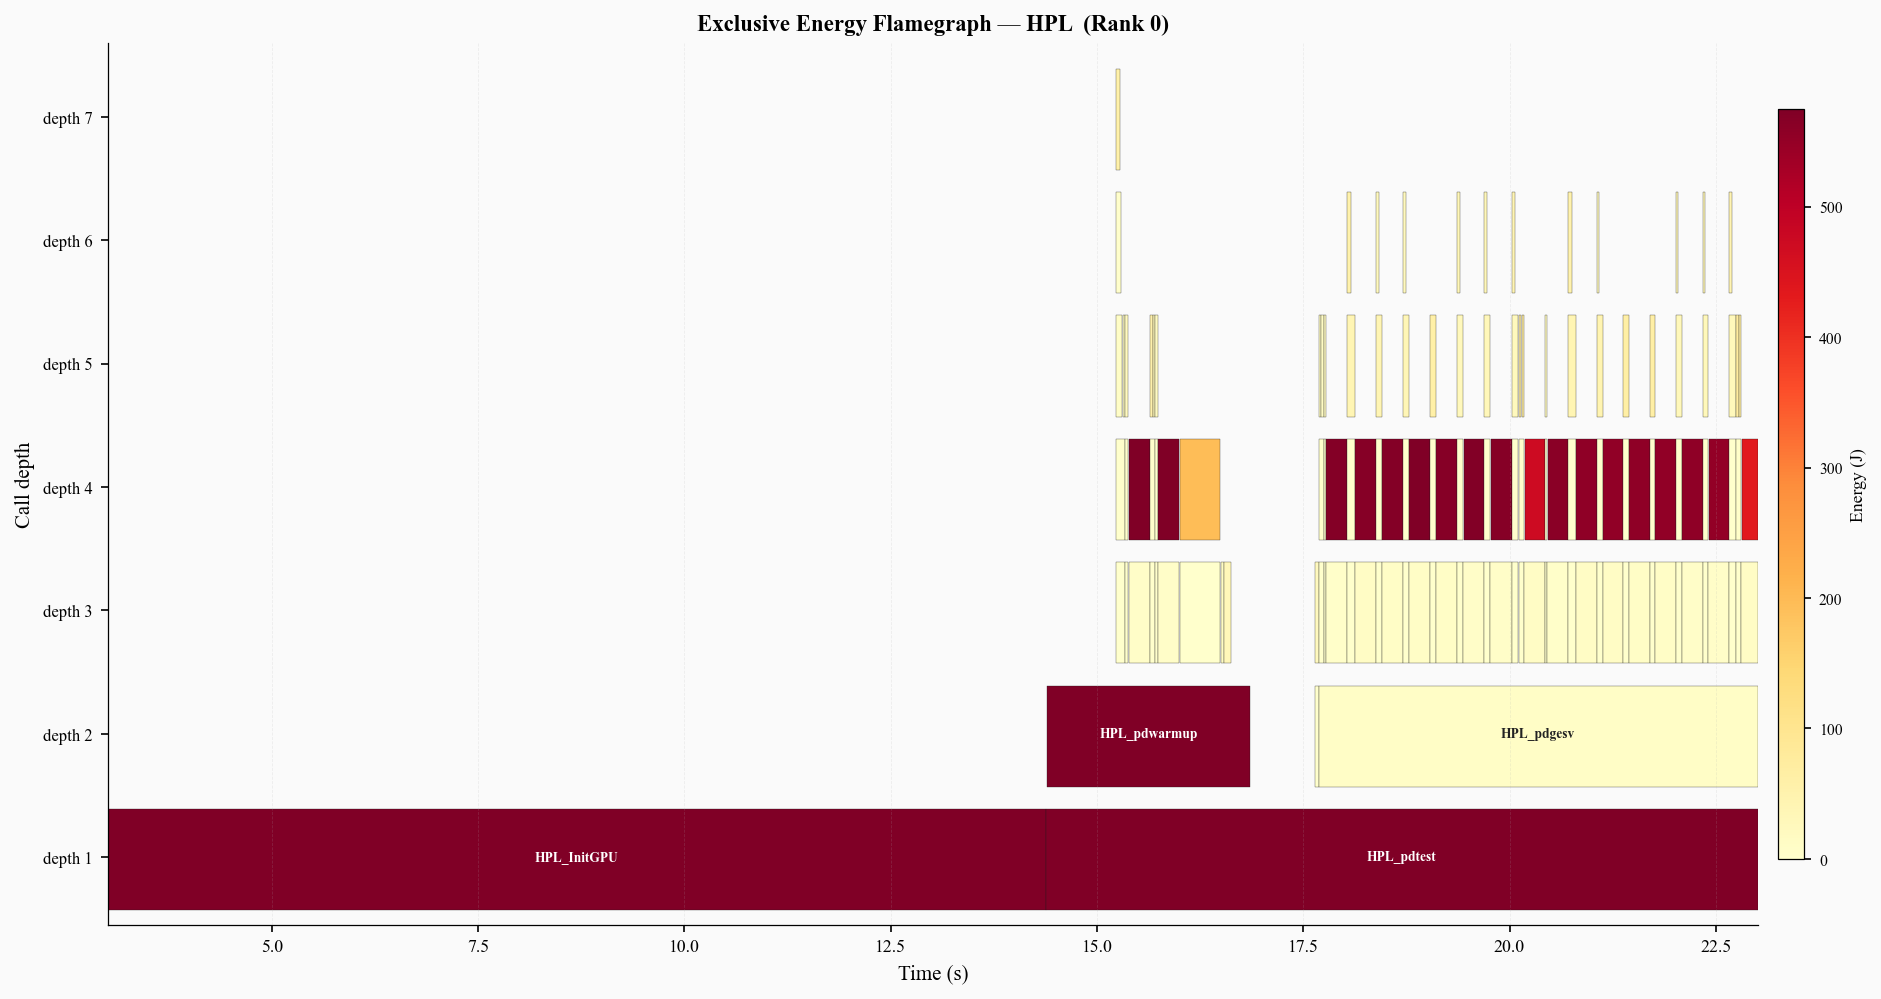

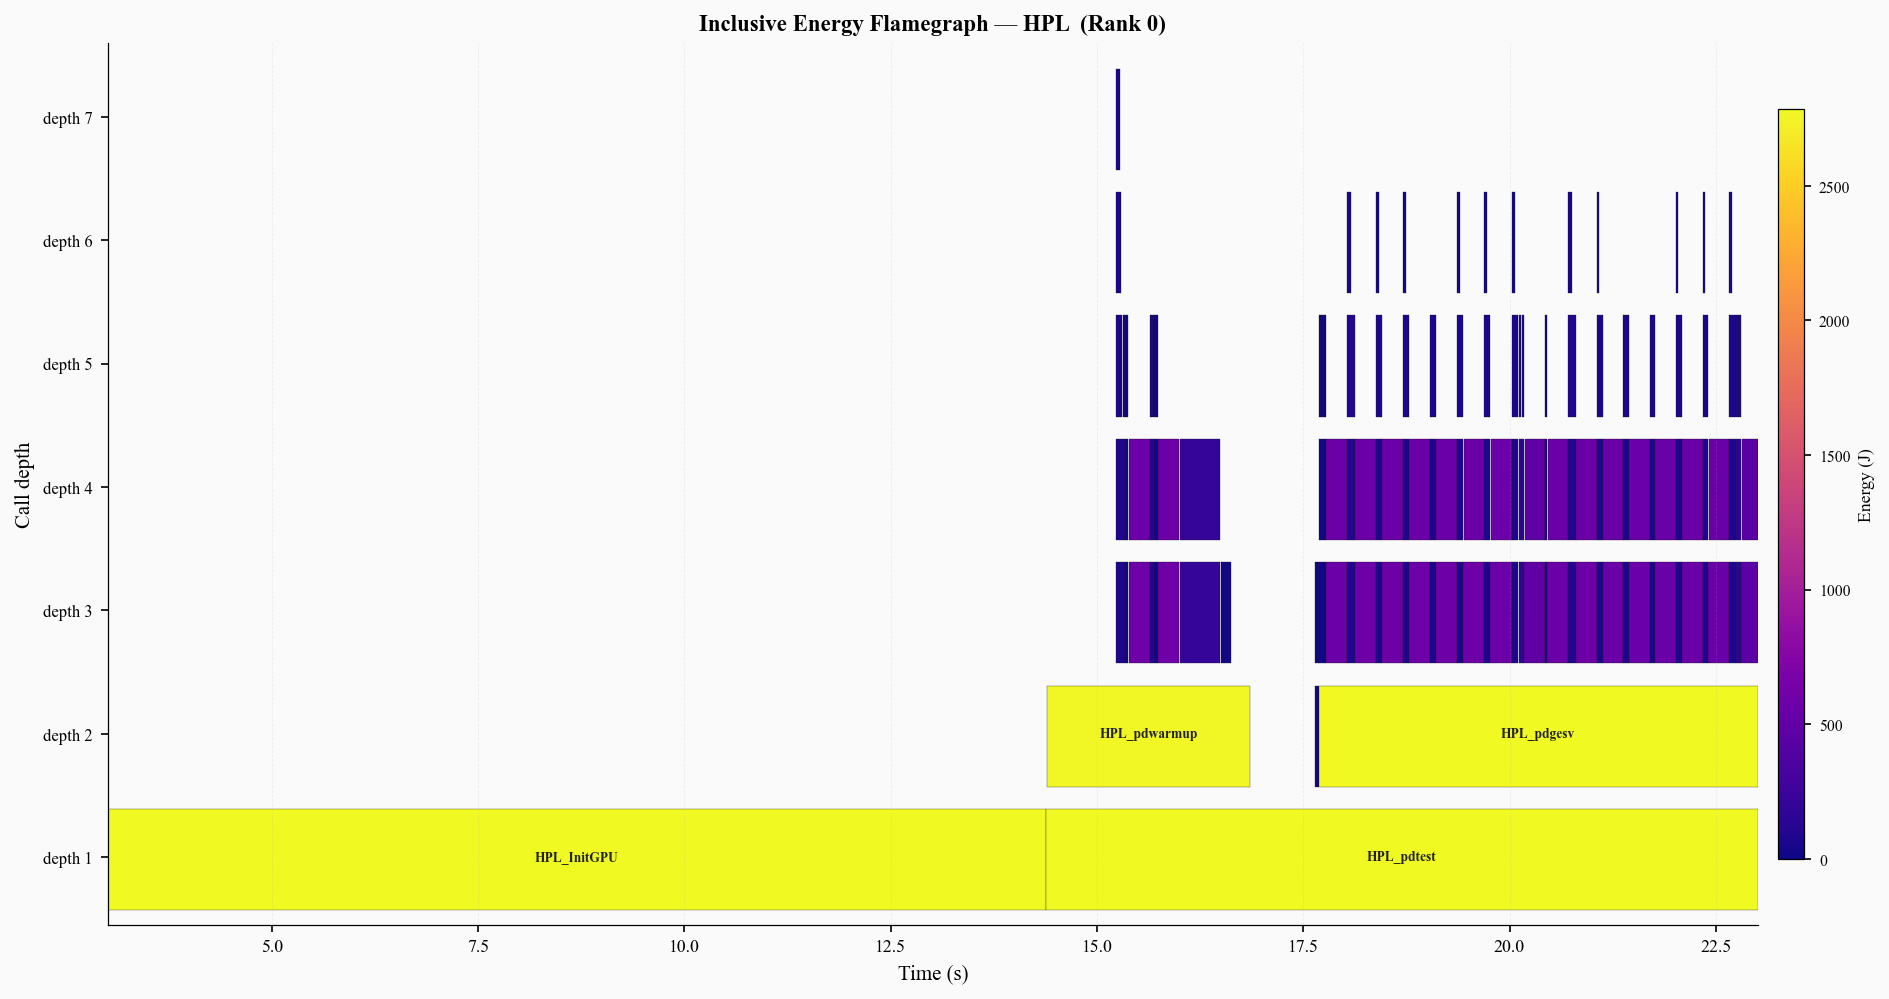

Building flame data for HPL-MxP …
  84 bars  ·  inclusive energy ≈ 12861 J


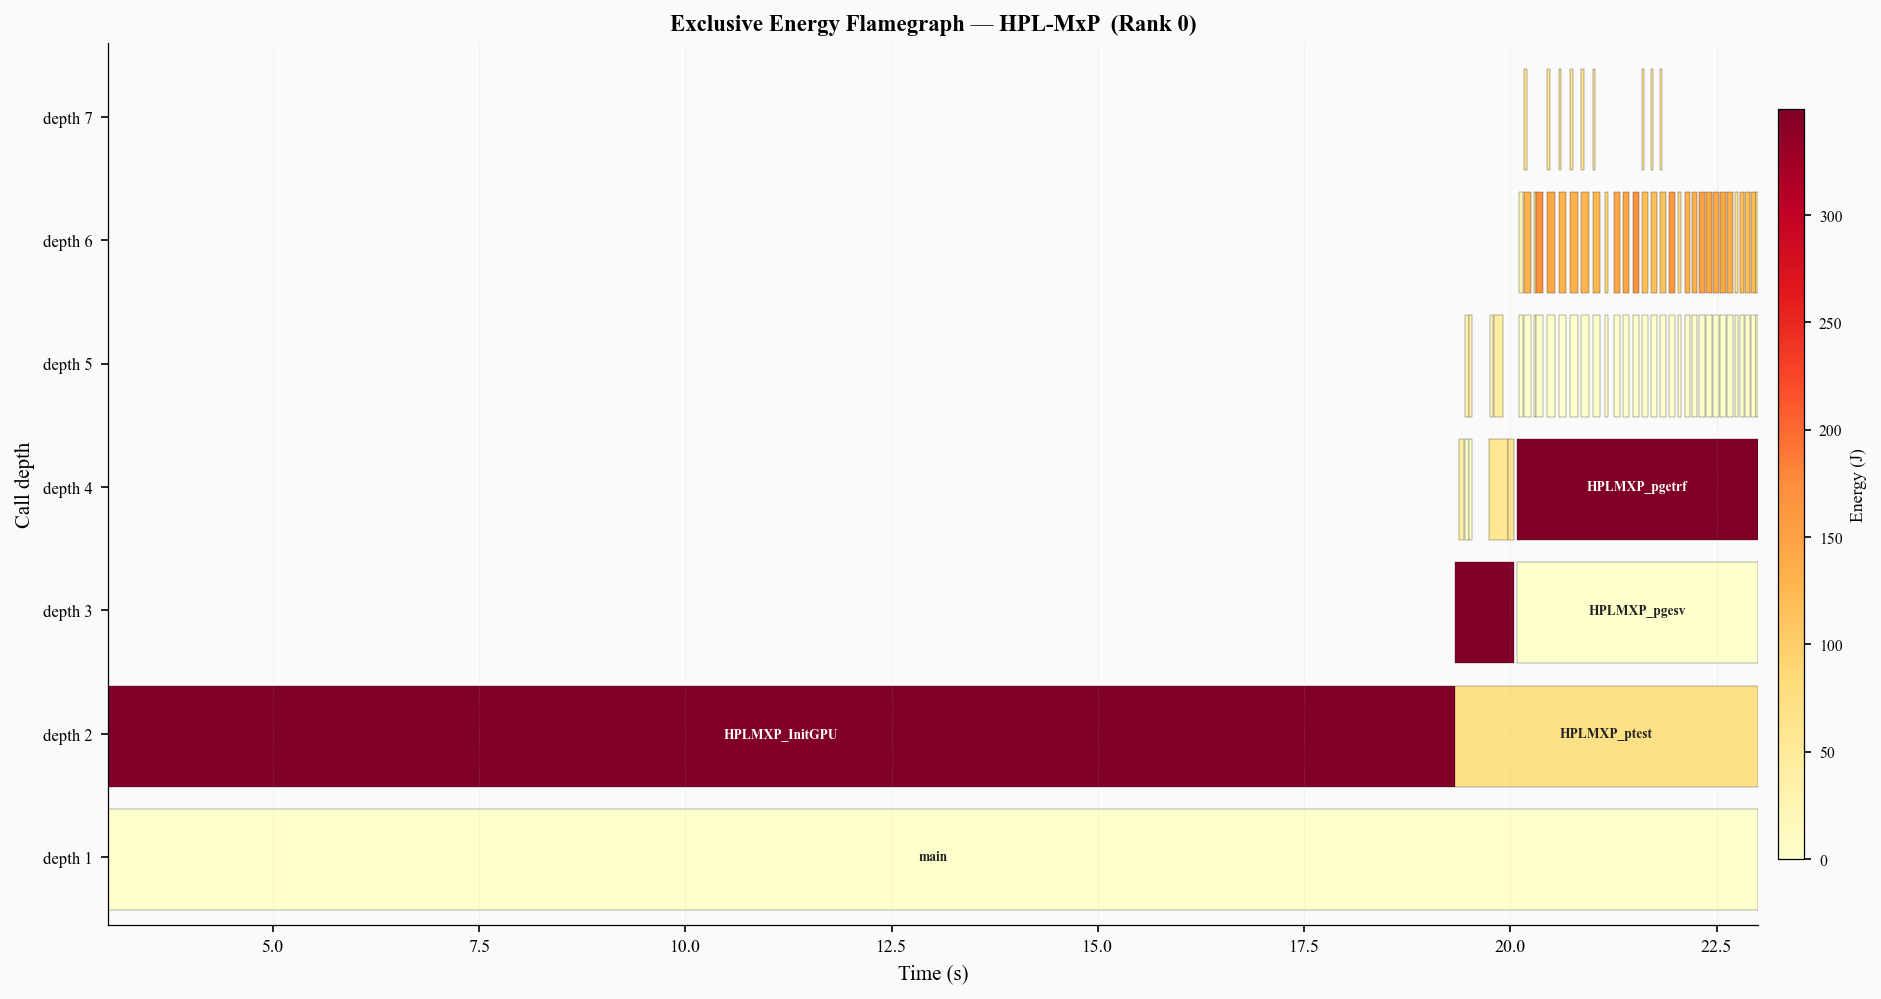

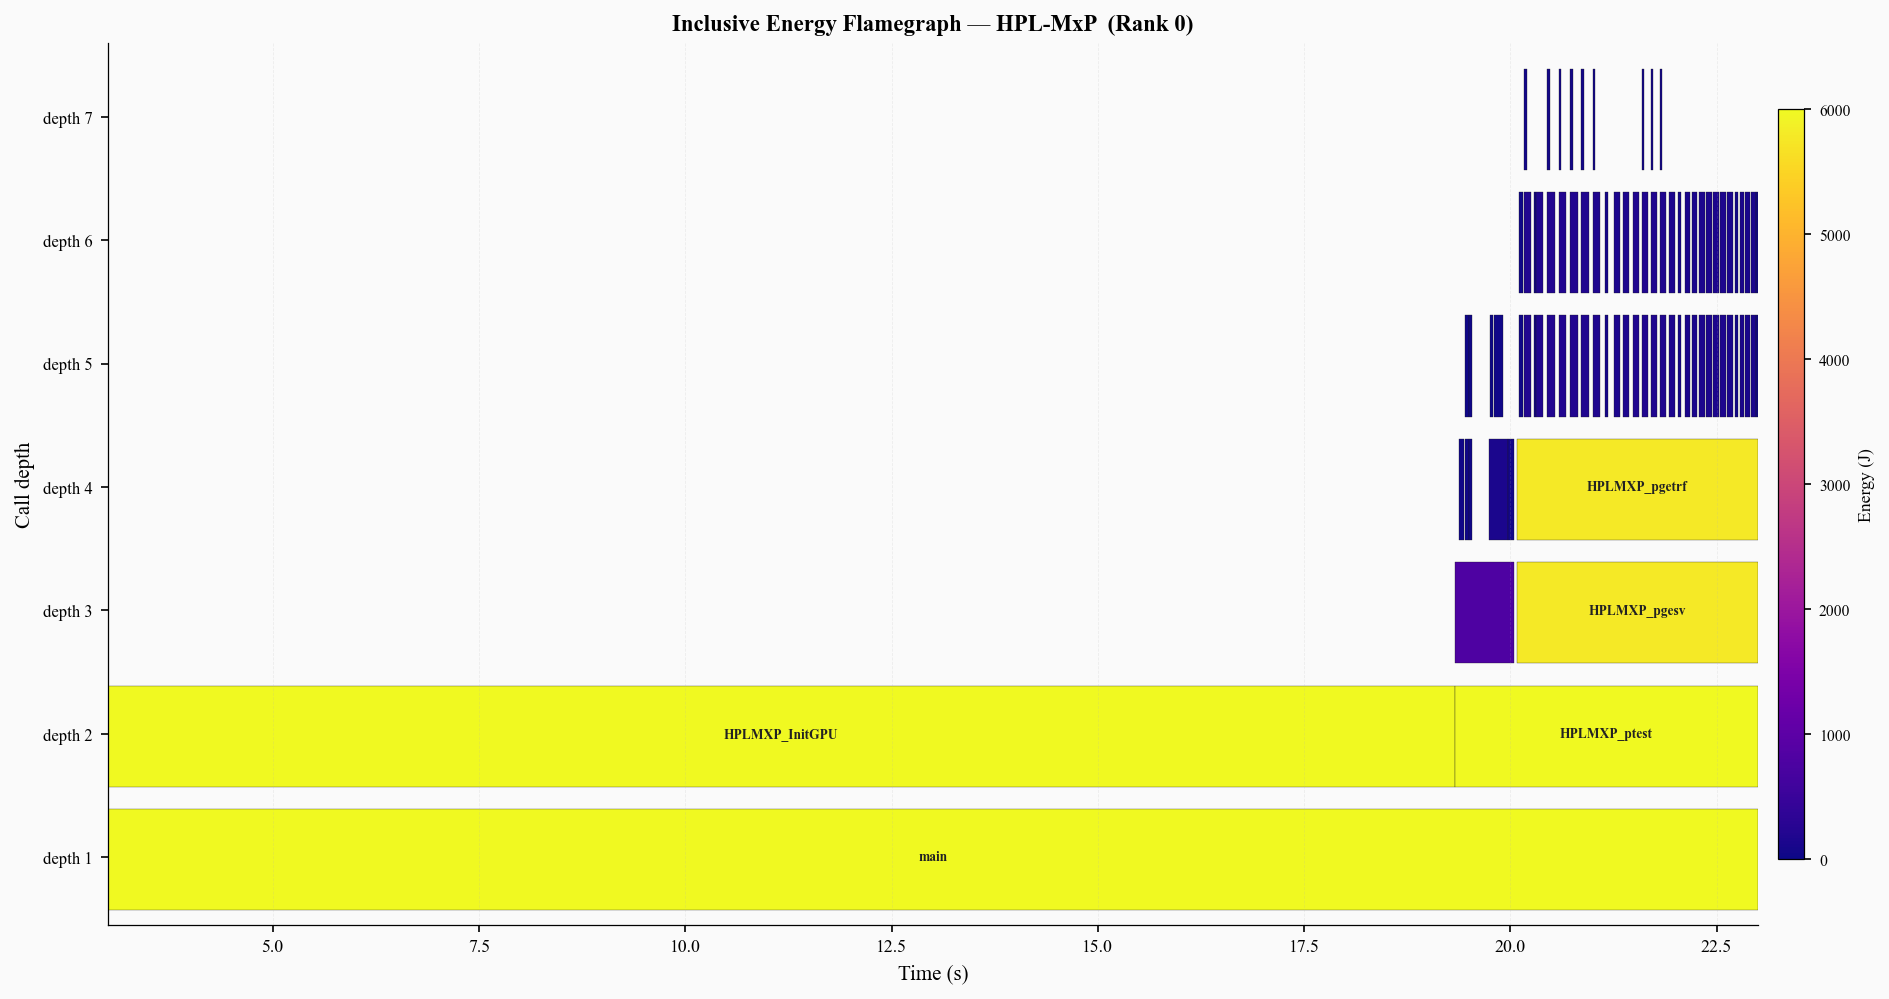

In [38]:
def load_power_series(metrics_path: Path):
    """Return (times, combined_power_W) from differentiated energy counters."""
    dm = pd.read_csv(metrics_path)
    series = []
    for dev in [0, 2, 4, 6]:
        sub = dm[dm['Metric Name'] == f'A2rocm_smi:::energy_count:device={dev}'].sort_values('Time')
        if len(sub) < 2: continue
        t  = sub['Time'].values
        e  = sub['Value'].values * 1e-6
        dt = np.diff(t); de = np.diff(e)
        p  = np.where((dt > 0) & (de >= 0), de / dt, 0.0)
        series.append((t[1:], p))
    if not series:
        return None, None
    L     = min(len(pt) for pt, _ in series)
    t_ref = series[0][0][:L]
    p_ref = sum(np.interp(t_ref, pt, pv) for pt, pv in series)
    return t_ref, p_ref


def integrate_windows(t0s, t1s, power_t, power_v):
    """Numerically integrate power over each [t0, t1] window."""
    out = np.zeros(len(t0s))
    for i, (t0, t1) in enumerate(zip(t0s, t1s)):
        if t1 <= t0: continue
        mask = (power_t > t0) & (power_t < t1)
        tw = np.empty(mask.sum() + 2)
        pw = np.empty_like(tw)
        tw[0]  = t0;  pw[0]  = float(np.interp(t0,  power_t, power_v))
        tw[-1] = t1;  pw[-1] = float(np.interp(t1,  power_t, power_v))
        tw[1:-1] = power_t[mask]; pw[1:-1] = power_v[mask]
        out[i] = float(np.sum((pw[:-1] + pw[1:]) * 0.5 * np.diff(tw))) if len(tw) >= 2 else 0.0
    return out


def build_flame_data(cg_path: Path, metrics_path: Path,
                     max_depth: int = 7, min_dur_s: float = 0.02,
                     t_window: tuple | None = None):
    """
    Returns DataFrame with columns:
      Depth, Name, Short, Library, Start Time, End Time, Duration,
      InclusiveE (J), ExclusiveE (J)
    filtered to the given time window.
    """
    df = pd.read_csv(cg_path, usecols=['Depth', 'Name', 'Start Time', 'End Time'])
    df['Duration'] = df['End Time'] - df['Start Time']
    df = df[(df['Depth'] <= max_depth) & (df['Duration'] >= min_dur_s)].copy()

    if t_window:
        t0w, t1w = t_window
        df = df[(df['End Time'] > t0w) & (df['Start Time'] < t1w)].copy()
        df['Start Time'] = df['Start Time'].clip(lower=t0w)
        df['End Time']   = df['End Time'].clip(upper=t1w)
        df['Duration']   = df['End Time'] - df['Start Time']

    df['Short']   = df['Name'].apply(short_name)
    df['Library'] = df['Name'].apply(classify)
    df = df.sort_values(['Start Time', 'Depth']).reset_index(drop=True)

    power_t, power_v = load_power_series(metrics_path)
    if power_t is None:
        return None

    # Inclusive energy: integrate power over each call's full window
    df['InclusiveE'] = integrate_windows(
        df['Start Time'].values, df['End Time'].values, power_t, power_v)

    # Exclusive energy: inclusive minus sum of immediate children
    # (calls at depth+1 whose time range is contained within this call)
    starts = df['Start Time'].values
    ends   = df['End Time'].values
    depths = df['Depth'].values
    inc    = df['InclusiveE'].values
    excl   = inc.copy()

    for i in range(len(df)):
        d, s, e = depths[i], starts[i], ends[i]
        # children = rows at depth d+1 strictly contained in [s, e]
        child_mask = (depths == d + 1) & (starts >= s) & (ends <= e)
        excl[i] = max(0.0, inc[i] - inc[child_mask].sum())

    df['ExclusiveE'] = excl
    return df


def draw_flamegraph(df: pd.DataFrame, energy_col: str, title: str,
                    cmap_name: str = 'YlOrRd', save_path: str | None = None):
    if df is None or df.empty:
        print(f"  [skip] no data for {title}"); return

    energies = df[energy_col].values
    vmax = np.percentile(energies[energies > 0], 97) if (energies > 0).any() else 1.0
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=vmax)

    max_d   = int(df['Depth'].max())
    t_start = df['Start Time'].min()
    t_end   = df['End Time'].max()

    fig, ax = plt.subplots(figsize=(14, max(4, max_d * 0.75 + 1.5)), facecolor=BG)
    ax.set_facecolor(BG)

    for _, row in df.iterrows():
        color = cmap(norm(row[energy_col]))
        rect  = mpatches.FancyBboxPatch(
            (row['Start Time'], row['Depth'] - 0.43),
            max(row['Duration'], 0.0),
            0.82,
            boxstyle='square,pad=0',
            facecolor=color, edgecolor='#1a1a1a', linewidth=0.15,
        )
        ax.add_patch(rect)

        # Label bar if wide enough to read
        trace_span = t_end - t_start
        if trace_span > 0 and row['Duration'] / trace_span > 0.04:
            brightness = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            txt_color  = 'white' if brightness < 0.55 else '#222'
            ax.text(row['Start Time'] + row['Duration'] * 0.5,
                    row['Depth'],
                    row['Short'][:22],
                    ha='center', va='center',
                    fontsize=6.5, color=txt_color, fontweight='bold',
                    clip_on=True)

    ax.set_xlim(t_start, t_end)
    ax.set_ylim(0.45, max_d + 0.6)
    ax.set_yticks(range(1, max_d + 1))
    ax.set_yticklabels([f'depth {d}' for d in range(1, max_d + 1)], fontsize=8)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Call depth', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.18, linestyle='--')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.01, aspect=28)
    cb.set_label('Energy (J)', fontsize=8.5)
    cb.ax.tick_params(labelsize=7.5)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, facecolor=BG, bbox_inches='tight')
    plt.show()


# ── Run for the first benchmark with both MPI rank CSVs and HIP metrics ──────
for bench_name, trial_path in BENCHMARKS.items():
    # Use rank 0 as the representative rank
    cg_path = trial_path / 'MPI Rank 0_Master_thread_callgraph.csv'
    m_path  = trial_path / 'MPI Rank 0_metrics.csv'
    if not cg_path.exists() or not m_path.exists():
        print(f"  [skip] {bench_name}: missing rank-0 files"); continue

    # Compute a 20-second representative window (skip first 3 s of MPI init)
    import csv
    with open(cg_path) as fh:
        reader = csv.DictReader(fh)
        first_row = next(reader)
    t0_trace = float(first_row['Start Time'])
    t_window = (t0_trace + 3.0, t0_trace + 23.0)

    print(f"Building flame data for {bench_name} …")
    flame_df = build_flame_data(cg_path, m_path, max_depth=7,
                                 min_dur_s=0.025, t_window=t_window)

    if flame_df is None or flame_df.empty:
        print(f"  [skip] {bench_name}: no data"); continue

    total_J = flame_df[flame_df['Depth'] == flame_df['Depth'].min()]['InclusiveE'].sum()
    print(f"  {len(flame_df):,} bars  ·  inclusive energy ≈ {total_J:.0f} J")

    draw_flamegraph(flame_df, 'ExclusiveE',
                    f'Exclusive Energy Flamegraph — {bench_name}  (Rank 0)',
                    cmap_name='YlOrRd',
                    save_path=f'fig3_exclusive_flame_{bench_name}.pdf')

    draw_flamegraph(flame_df, 'InclusiveE',
                    f'Inclusive Energy Flamegraph — {bench_name}  (Rank 0)',
                    cmap_name='plasma',
                    save_path=f'fig4_inclusive_flame_{bench_name}.pdf')


## Figure 3: Library Energy Breakdown

For each discovered benchmark, show how GPU energy is split across compute libraries.  
Results update automatically when new benchmark data is placed in `app-traces/`.

In [39]:
def compute_benchmark_energy(bench_name: str, trial_path: Path) -> pd.DataFrame | None:
    node_ranks = make_node_ranks(trial_path)
    if not node_ranks:
        return None
    ens = Ensemble.from_trace_paths([str(trial_path)], node_ranks, configs)
    parts = []
    for metric in ENERGY_DEVICES:
        try:
            df = ens.attribute(metric, topology_resolver=mpi_topology_resolver,
                               strategy='exclusive').to_pandas()
            if len(df) > 0:
                parts.append(df)
        except Exception:
            pass
    if not parts:
        return None
    attr = pd.concat(parts, ignore_index=True)
    attr['Library'] = attr['Name'].apply(classify)
    attr['Bench']   = bench_name
    return attr

bench_energy = {}
for bench_name, trial_path in BENCHMARKS.items():
    print(f"Loading {bench_name}...")
    df = compute_benchmark_energy(bench_name, trial_path)
    if df is not None:
        bench_energy[bench_name] = df
        print(f"  {len(df):,} attributed rows")

if not bench_energy:
    print("No attribution data available.")


Loading HPL...


Loading Runs: 100%|██████████| 1/1 [00:11<00:00, 11.51s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.41s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


...

Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 17.32it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00, 16.35it/s]


  536,257 attributed rows


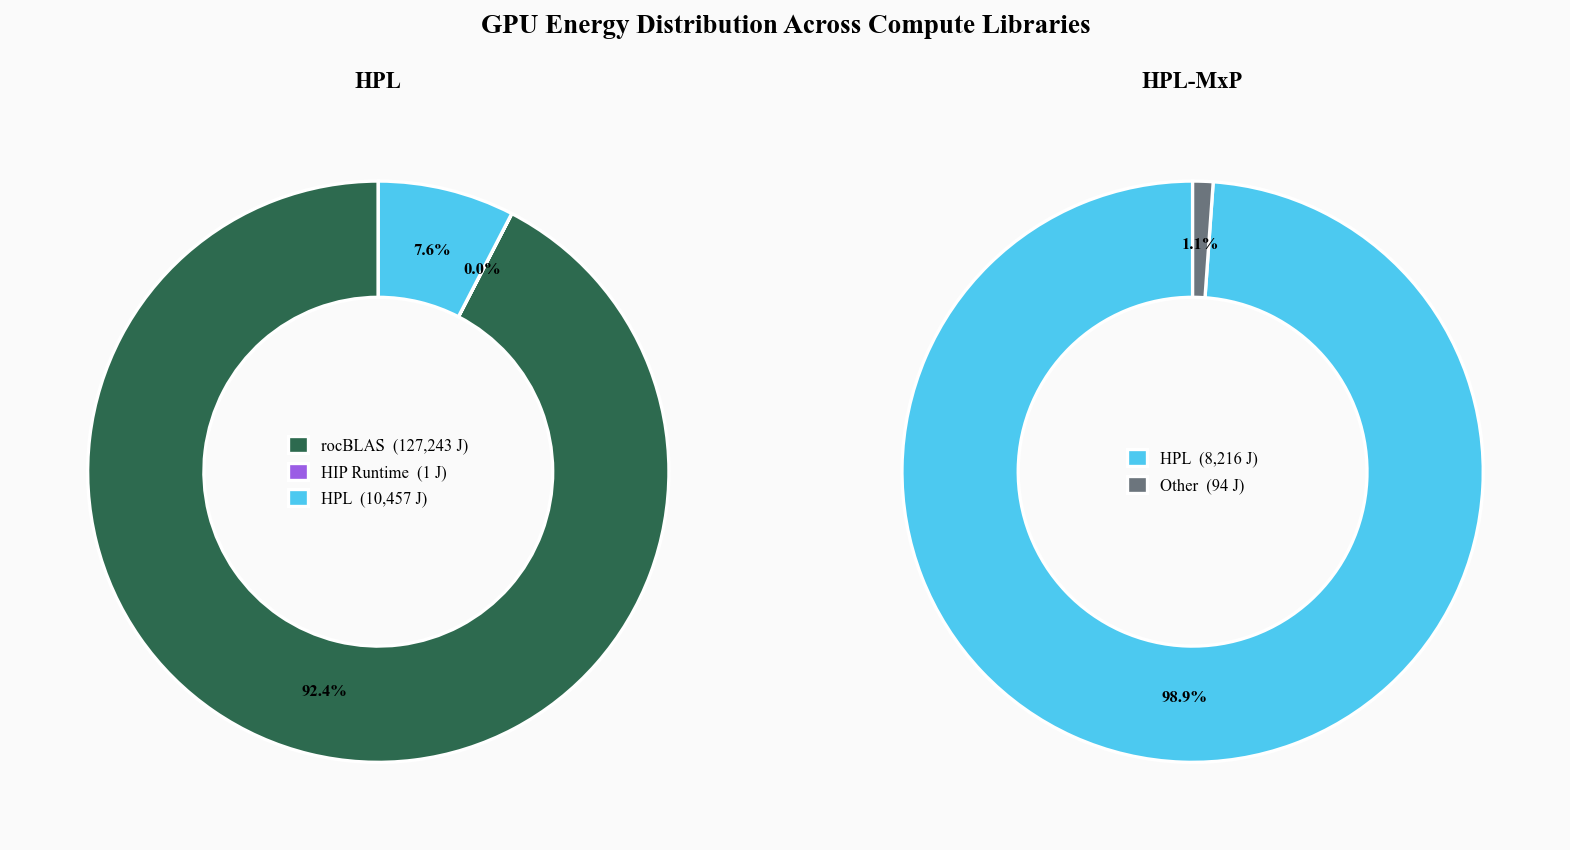

In [40]:
if bench_energy:
    n_bench = len(bench_energy)
    fig, axes = plt.subplots(1, n_bench, figsize=(5.5 * n_bench, 5.5), facecolor=BG)
    if n_bench == 1:
        axes = [axes]

    for ax, (bench_name, attr) in zip(axes, bench_energy.items()):
        ax.set_facecolor(BG)

        # Compute energy share by library (exclude MPI idle)
        compute = attr[attr['Library'] != 'MPI']
        lib_e   = compute.groupby('Library')['Value'].sum()
        lib_e   = lib_e.reindex([c for c in LIB_ORDER if c in lib_e.index])
        colors  = [PALETTE[c] for c in lib_e.index]

        wedges, _, autotexts = ax.pie(
            lib_e.values, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.78,
            wedgeprops=dict(width=0.40, edgecolor='white', linewidth=1.6))
        for t in autotexts:
            t.set_fontsize(8); t.set_fontweight('bold')

        legend_labels = [f"{lib}  ({lib_e[lib]:,.0f} J)" for lib in lib_e.index]
        ax.legend(wedges, legend_labels, loc='center', fontsize=8,
                  frameon=False, handlelength=1.2, handleheight=1.2)
        ax.set_title(bench_name, fontsize=11, fontweight='bold', pad=10)

    fig.suptitle('GPU Energy Distribution Across Compute Libraries',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig('fig3_library_donuts.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 4: Top Functions by Energy

Horizontal bar chart of the top-20 most energy-intensive functions, one panel per benchmark.

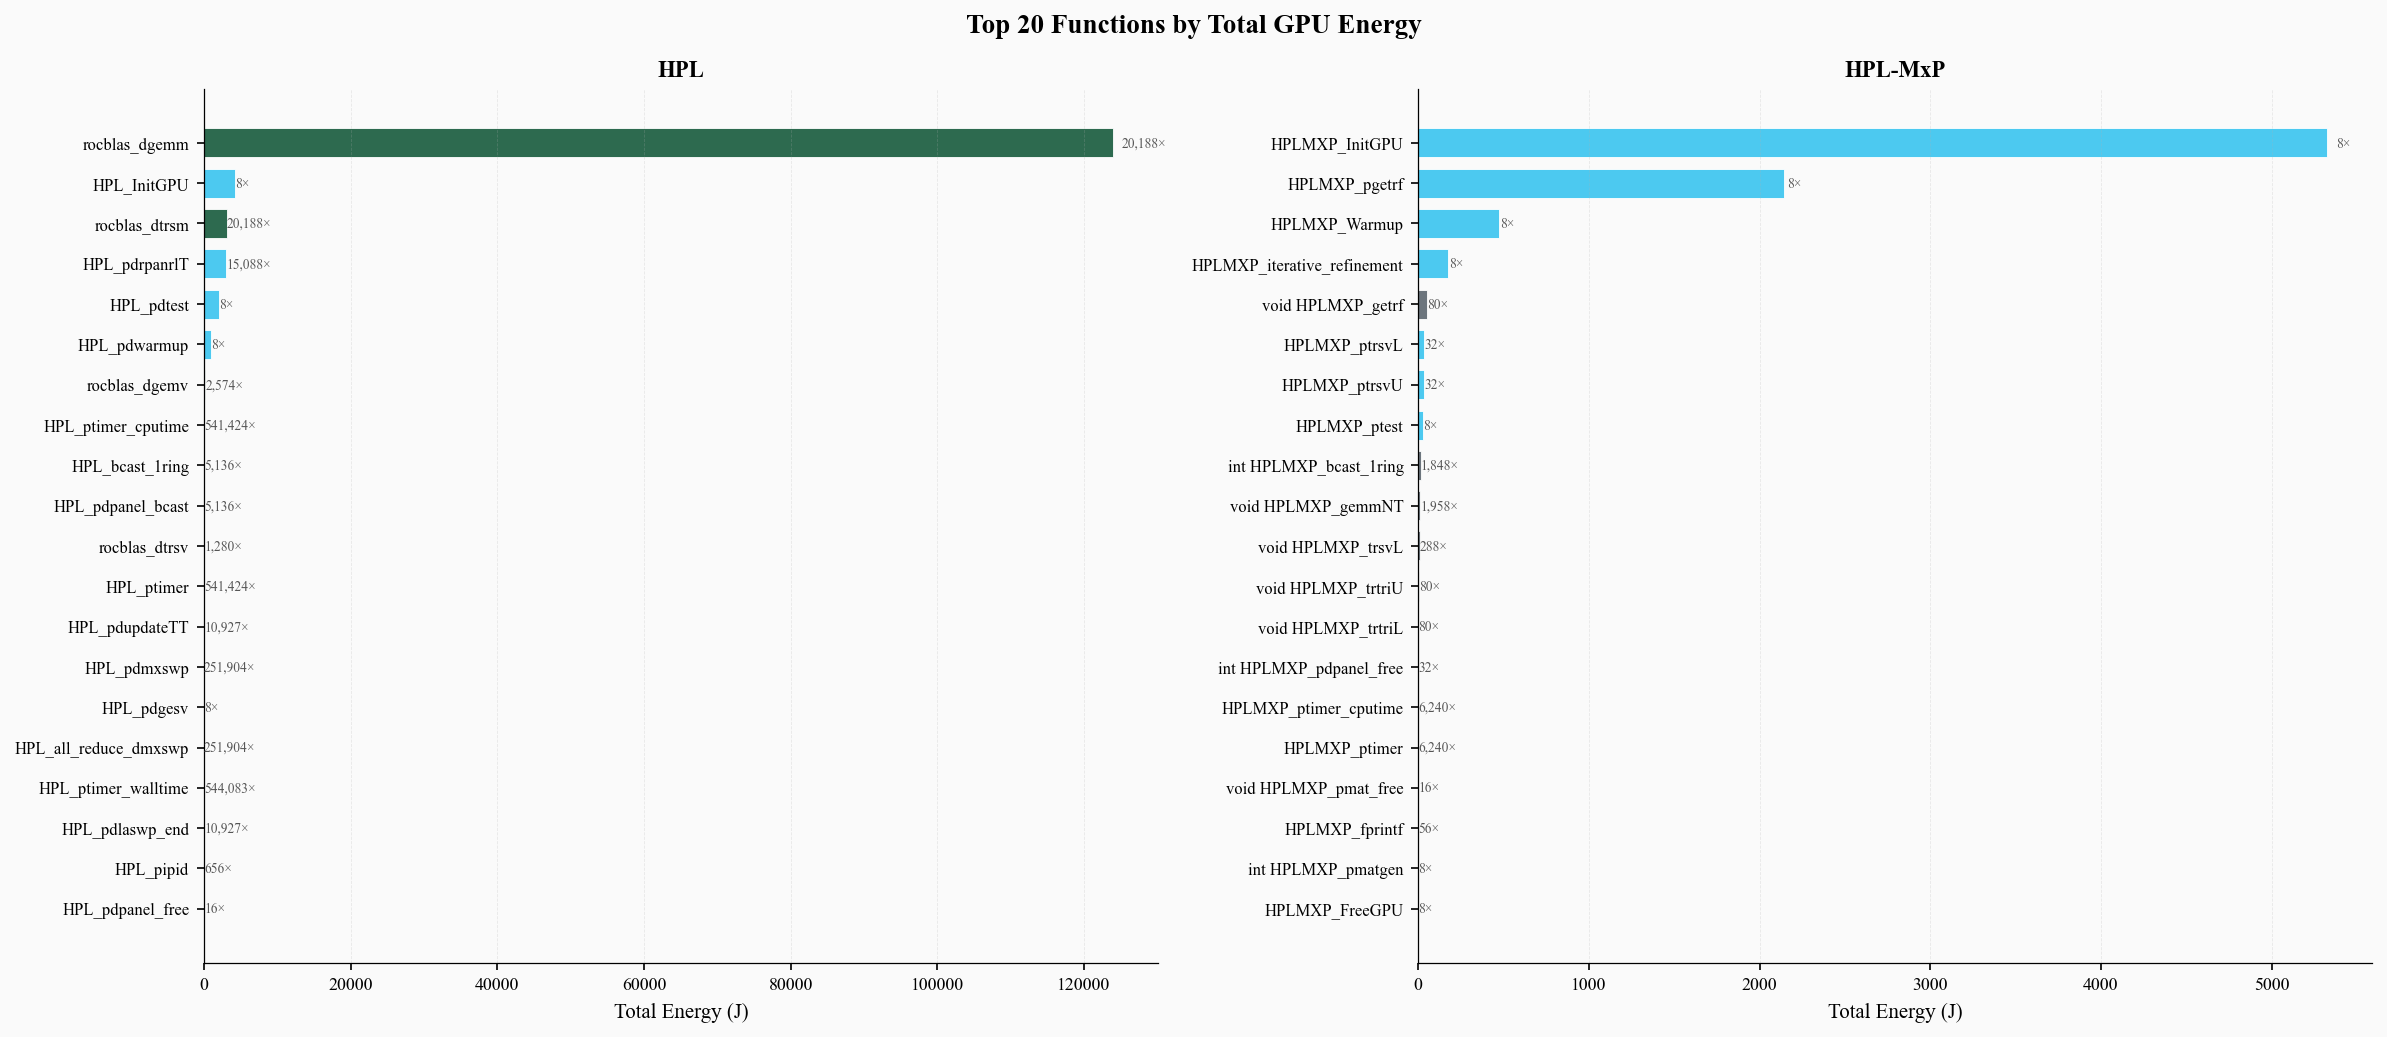

In [41]:
if bench_energy:
    n_bench = len(bench_energy)
    TOP_N = 20

    fig, axes = plt.subplots(1, n_bench,
                              figsize=(8 * n_bench, 7),
                              facecolor=BG)
    if n_bench == 1:
        axes = [axes]

    for ax, (bench_name, attr) in zip(axes, bench_energy.items()):
        ax.set_facecolor(BG)
        compute = attr[attr['Library'] != 'MPI'].copy()
        compute['ShortName'] = compute['Name'].apply(short_name)
        func_e  = (compute.groupby(['ShortName', 'Library'])
                   .agg(total_energy=('Value', 'sum'), count=('Value', 'size'))
                   .reset_index()
                   .sort_values('total_energy', ascending=False)
                   .head(TOP_N))

        colors = [PALETTE.get(row['Library'], '#6c757d')
                  for _, row in func_e.iterrows()]
        ax.barh(range(len(func_e)), func_e['total_energy'].values,
                color=colors, edgecolor='white', linewidth=0.4, height=0.72)
        ax.set_yticks(range(len(func_e)))
        ax.set_yticklabels(func_e['ShortName'].values, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Total Energy (J)')
        ax.set_title(bench_name, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.25, linestyle='--')

        # Call count annotations
        for i, (_, row) in enumerate(func_e.iterrows()):
            ax.text(row['total_energy'] * 1.01, i,
                    f"{row['count']:,}×", va='center', fontsize=6.5, color='#555')

    fig.suptitle(f'Top {TOP_N} Functions by Total GPU Energy',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig('fig4_top_functions.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()
